# Analyse marketing et prédiction du churn

## Données utilisées
- **sales_data** : clé `Product_ID`, `Customer_ID`, `Channel`
- **products_data** : clé `Product_ID`
- **customers_data** : clé `Customer_ID`
- **marketing_data** : clé `Channel`

## M1 : Chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Définition des chemins
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data" / "input"

# Chargement des données
customers = pd.read_csv(DATA_DIR / "customers_data.csv")
products = pd.read_csv(DATA_DIR / "products_data.csv")
sales = pd.read_csv(DATA_DIR / "sales_data.csv")
marketing = pd.read_csv(DATA_DIR / "marketing_data.csv")

## M2 : Exploration des données

In [2]:
# Nettoyage : types, valeurs manquantes et doublons
sales.info()
sales.describe()
sales.isna().sum()
sales.duplicated().sum()

products.info()
products.describe()
products.isna().sum()
products.duplicated().sum()

customers.info()
customers.describe()
customers.isna().sum()
customers.duplicated().sum()

marketing.info()
marketing.describe()
marketing.isna().sum()
marketing.duplicated().sum()

# Fusion des tables et calcul du prix de vente
sales_full = sales.merge(customers, on='Customer_ID', how='inner')
sales_full = sales_full.merge(products, on='Product_ID', how='inner')

sales_full['Sale_Price'] = sales_full['Quantity'] * sales_full['Price']
total_spent_per_customer = sales_full.groupby('Customer_ID')['Sale_Price'].sum()
sales_full['Total_Spent'] = sales_full['Customer_ID'].map(total_spent_per_customer).fillna(0)
customers['Total_Spent'] = customers['Customer_ID'].map(total_spent_per_customer).fillna(0)

sales_full.info()
sales_full.head()

<class 'pandas.DataFrame'>
RangeIndex: 9892 entries, 0 to 9891
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sale_ID      9892 non-null   int64  
 1   Product_ID   9892 non-null   str    
 2   Customer_ID  9892 non-null   int64  
 3   Date         9892 non-null   str    
 4   Quantity     9892 non-null   int64  
 5   Sale_Price   9892 non-null   float64
 6   Channel      9892 non-null   str    
dtypes: float64(1), int64(3), str(3)
memory usage: 541.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    100 non-null    str    
 1   Product_Name  100 non-null    str    
 2   Category      100 non-null    str    
 3   Price         100 non-null    float64
dtypes: float64(1), str(3)
memory usage: 3.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data c

,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Name,Age,Gender,Location,Join_Date,Total_Spent,Product_Name,Category,Price
0,1,P029,2001,2023-06-18,1,76.40,Store,Adam,41,Female,Boston,2023-05-31,76.40,Baskets Minimalistes,Footering,76.40
1,2,P047,2003,2025-04-06,1,56.07,Online,Bob,37,Male,Chicago,2024-10-27,175.97,Montre Classique,Accessoiries,56.07
2,3,P022,2003,2025-12-01,1,119.90,Online,Bob,37,Male,Chicago,2024-10-27,175.97,Escarpins,Footering,119.90
3,4,P010,2004,2024-02-04,2,179.98,Online,Sarah,31,Female,Seattle,2023-12-10,290.57,Sweat à Capuche,Clothing,89.99
4,5,P020,2004,2024-09-22,1,110.59,Online,Sarah,31,Female,Seattle,2023-12-10,290.57,Baskets de Course,Footering,110.59


### Visualisations

- Meilleurs clients
- Produit le plus vendu
- Rapport canal / ventes
- Catégorie la plus vendue
- Rapport âge / ventes

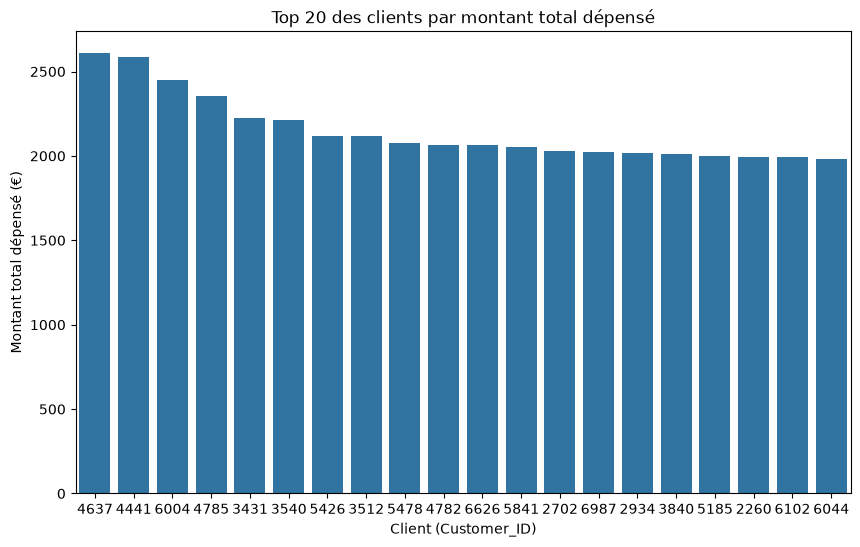

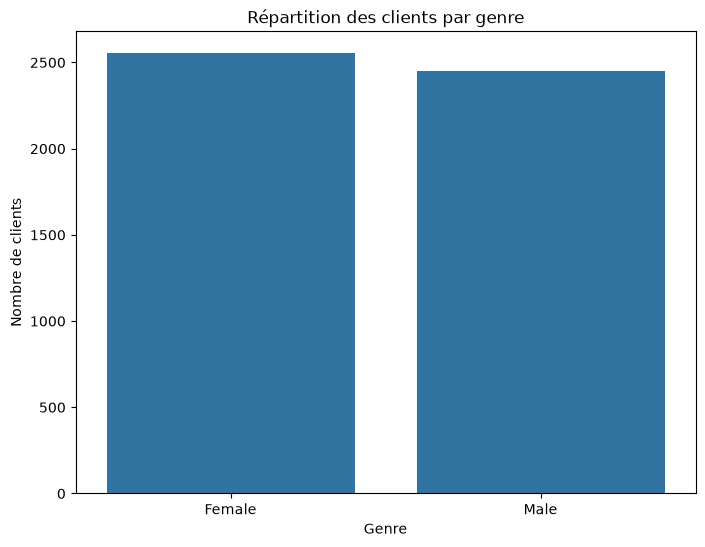

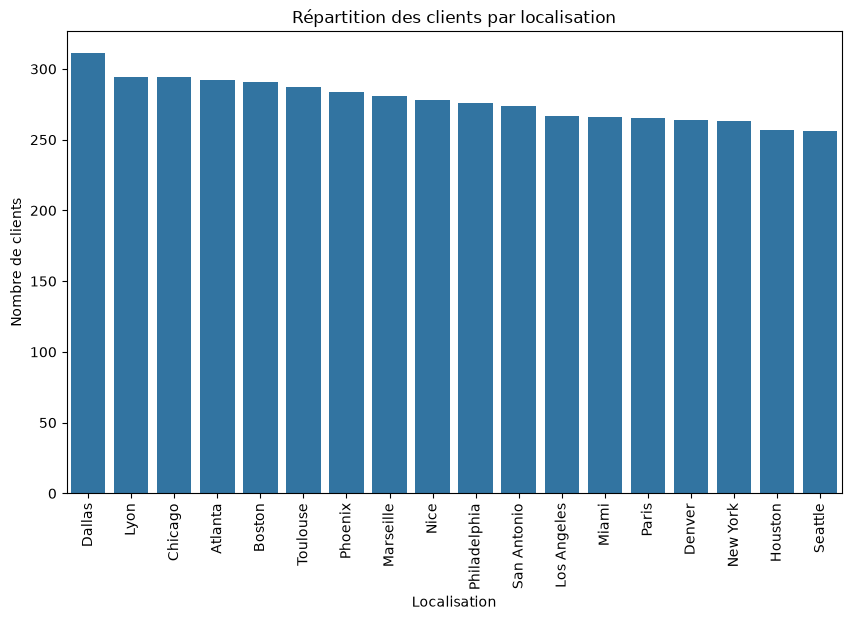

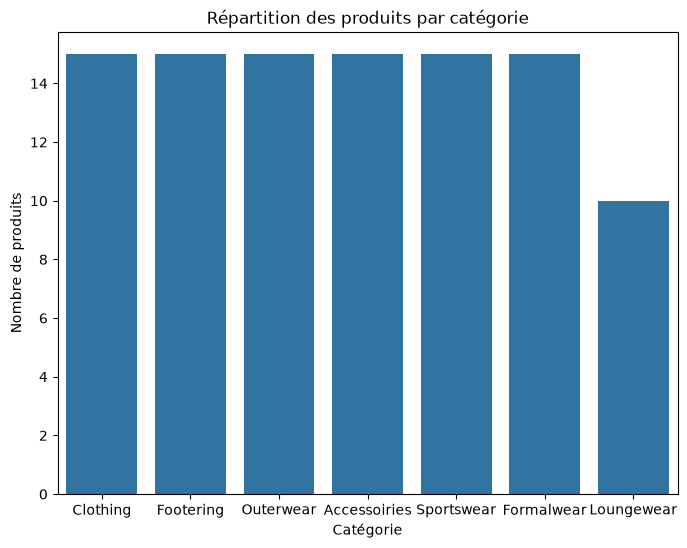

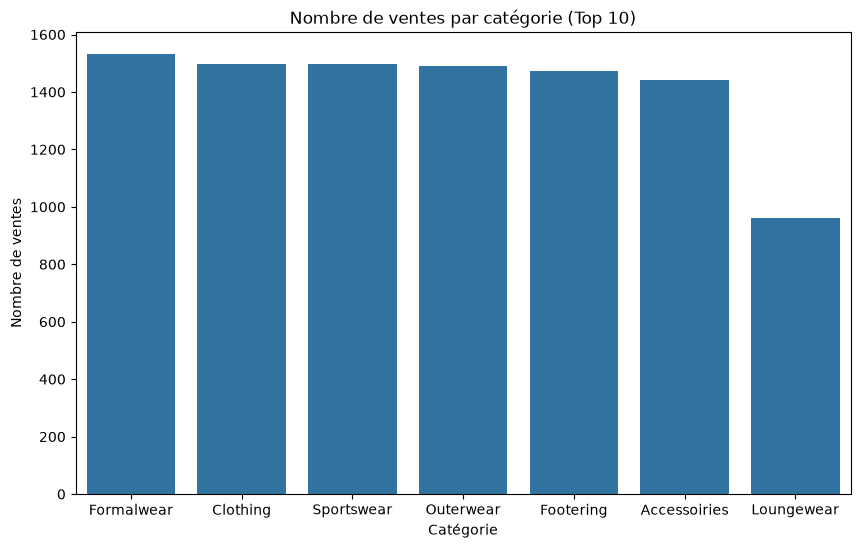

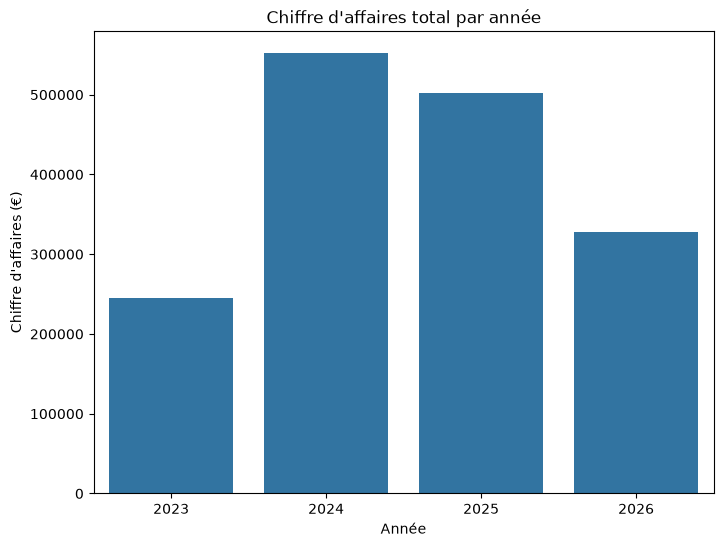

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns

# Top 20 des clients par montant total dépensé
top_customers = customers.sort_values(by='Total_Spent', ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(y='Total_Spent', x='Customer_ID', data=top_customers, order=top_customers['Customer_ID'])
plt.xlabel('Client (Customer_ID)')
plt.ylabel('Montant total dépensé (€)')
plt.title('Top 20 des clients par montant total dépensé')
plt.show()

# Répartition des clients par genre
gender_counts = customers['Gender'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.xlabel('Genre')
plt.ylabel('Nombre de clients')
plt.title('Répartition des clients par genre')
plt.show()

# Répartition des clients par localisation
location_counts = customers['Location'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.index, y=location_counts.values)
plt.xlabel('Localisation')
plt.ylabel('Nombre de clients')
plt.title('Répartition des clients par localisation')
plt.xticks(rotation=90)
plt.show()

# Répartition des produits par catégorie
category_counts = products['Category'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xlabel('Catégorie')
plt.ylabel('Nombre de produits')
plt.title('Répartition des produits par catégorie')
plt.show()

# Nombre de ventes par catégorie (top 10)
top_products = sales_full['Category'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(y=top_products.values, x=top_products.index)
plt.xlabel('Catégorie')
plt.ylabel('Nombre de ventes')
plt.title('Nombre de ventes par catégorie (Top 10)')
plt.show()

# Chiffre d'affaires total par année
sales_full['Year'] = pd.to_datetime(sales_full['Date']).dt.year
yearly_sales = sales_full.groupby('Year')['Sale_Price'].sum()
plt.figure(figsize=(8, 6))
sns.barplot(x=yearly_sales.index, y=yearly_sales.values)
plt.xlabel('Année')
plt.ylabel("Chiffre d'affaires (€)")
plt.title("Chiffre d'affaires total par année")
plt.show()

## M3 : Segmentation client

Créer des clusters de clients basés sur l'âge, les dépenses et les produits achetés.

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

customer_features = sales_full.copy()

features = ['Age', 'Total_Spent', 'Product_Name']
X = sales_full[features]

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), ['Age', 'Total_Spent']),
        ('product', OneHotEncoder(handle_unknown='ignore'), ['Product_Name'])
    ]
)

X_scaled = preprocessor.fit_transform(X)
X_dense = X_scaled.toarray() if hasattr(X_scaled, "toarray") else X_scaled

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

tsne = TSNE(n_components=2, init="random", random_state=42)
X_tsne = tsne.fit_transform(X_dense)

### Sélection du nombre de clusters (k)

--- Sélection du nombre de clusters ---
   k  silhouette       inertia
0  2    0.226036  22732.383725
1  3    0.208300  17778.557501
2  4    0.181786  16059.170884
3  5    0.143209  14897.265855
4  6    0.139790  14040.992638


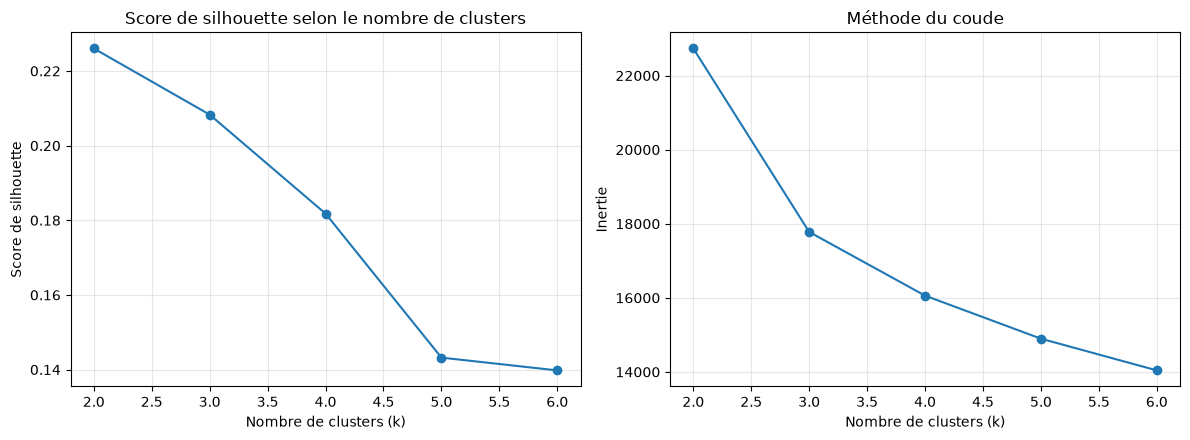


Nombre de clusters retenu (silhouette maximal) : 2


In [5]:
resultats_k = []
for k in range(2, 7):
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels_test)
    resultats_k.append({"k": k, "silhouette": score, "inertia": km_test.inertia_})

resultats_k_df = pd.DataFrame(resultats_k)
print("--- Sélection du nombre de clusters ---")
print(resultats_k_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(resultats_k_df["k"], resultats_k_df["silhouette"], marker="o")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Score de silhouette")
axes[0].set_title("Score de silhouette selon le nombre de clusters")
axes[0].grid(alpha=0.3)

axes[1].plot(resultats_k_df["k"], resultats_k_df["inertia"], marker="o")
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Inertie")
axes[1].set_title("Méthode du coude")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# k retenu : celui qui maximise le score de silhouette
N_CLUSTERS = int(resultats_k_df.loc[resultats_k_df["silhouette"].idxmax(), "k"])
print(f"\nNombre de clusters retenu (silhouette maximal) : {N_CLUSTERS}")

### Clustering K-Means et clustering hiérarchique

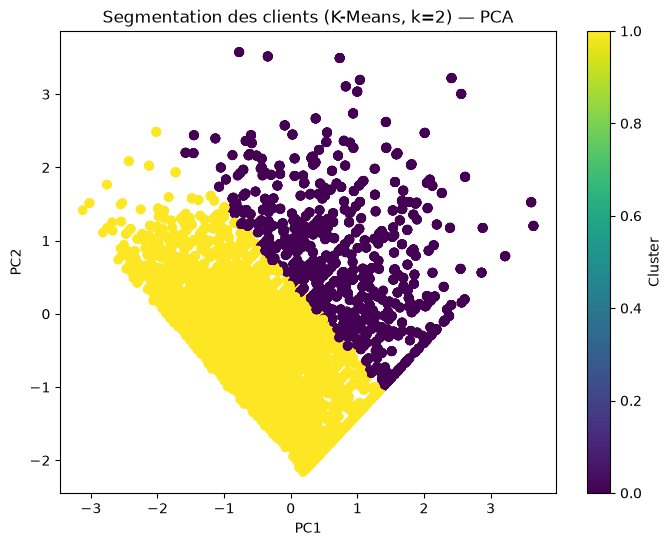

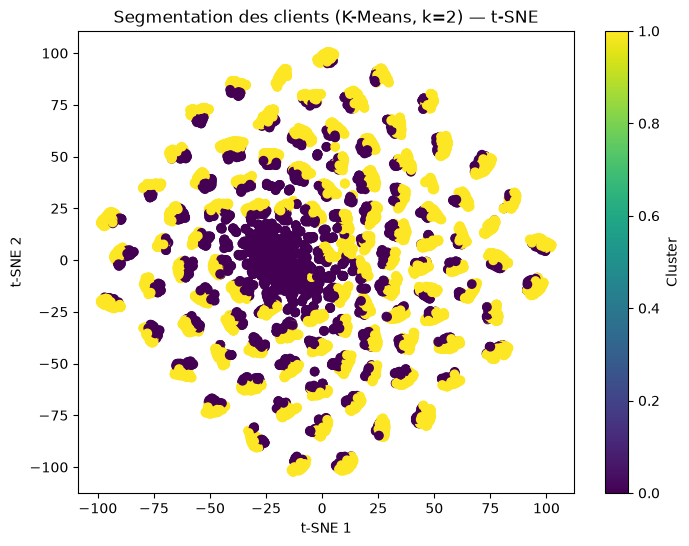

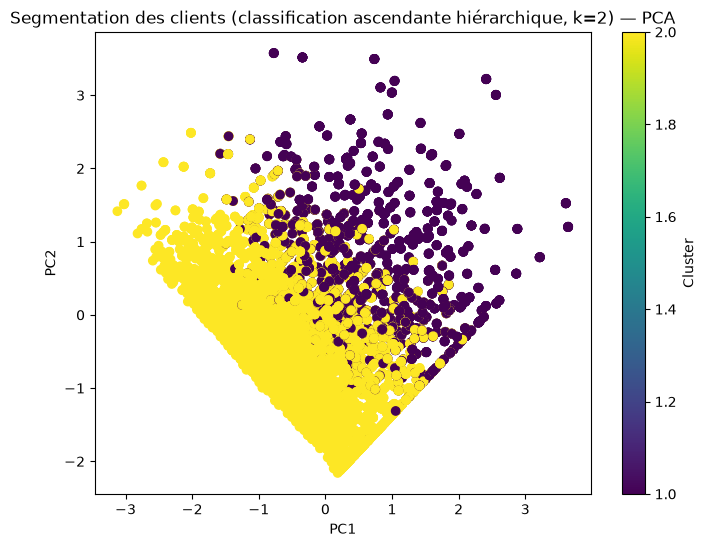

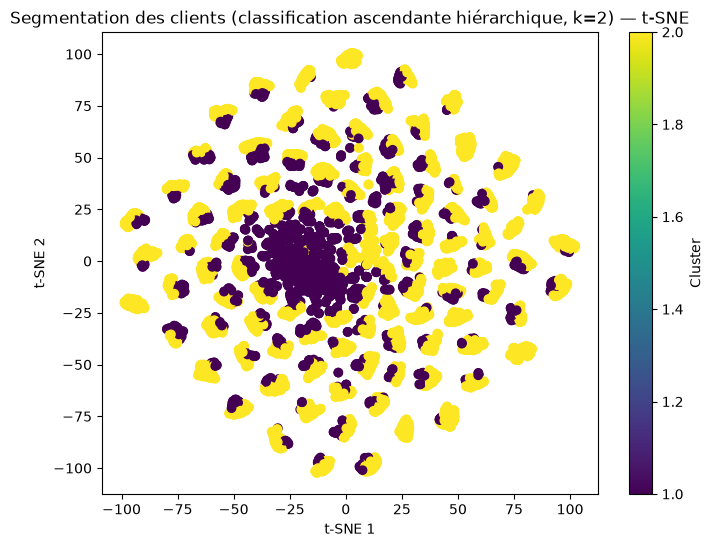

Score de silhouette (hiérarchique) : 0.19186430140422328
Score de silhouette (K-Means) : 0.2260358095023167


In [6]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
customer_features['cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features['cluster'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Segmentation des clients (K-Means, k={N_CLUSTERS}) — PCA')
plt.colorbar(label='Cluster')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=customer_features['cluster'], cmap='viridis')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f'Segmentation des clients (K-Means, k={N_CLUSTERS}) — t-SNE')
plt.colorbar(label='Cluster')
plt.show()

linked = linkage(X_dense, method='ward')
customer_features['cluster_hierarchical'] = fcluster(linked, N_CLUSTERS, criterion='maxclust')

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_features['cluster_hierarchical'], cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Segmentation des clients (classification ascendante hiérarchique, k={N_CLUSTERS}) — PCA')
plt.colorbar(label='Cluster')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=customer_features['cluster_hierarchical'], cmap='viridis')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f'Segmentation des clients (classification ascendante hiérarchique, k={N_CLUSTERS}) — t-SNE')
plt.colorbar(label='Cluster')
plt.show()

score_hierarchique = silhouette_score(X_scaled, customer_features['cluster_hierarchical'])
print("Score de silhouette (hiérarchique) :", score_hierarchique)

score_kmeans = silhouette_score(X_scaled, customer_features['cluster'])
print("Score de silhouette (K-Means) :", score_kmeans)

## M4 : Profilage des segments

Identifier les caractéristiques, préférences et personas de chaque segment.

In [7]:
cluster_profiles = customer_features.groupby('cluster').agg({
    'Age': 'mean',
    'Total_Spent': 'mean',
    'Customer_ID': 'count',
}).rename(columns={'Customer_ID': 'segment_size'})

print("--- Profils des segments (personas) ---")
print(cluster_profiles)

# Noms de segments générés dynamiquement, triés par dépense moyenne croissante
labels_possibles = [
    'Faible dépense', 'Dépense modérée', 'Dépense élevée',
    'Très forte dépense', 'Segment additionnel'
]
cluster_profiles_sorted = cluster_profiles.sort_values('Total_Spent')
cluster_names = {
    cluster_id: labels_possibles[i] if i < len(labels_possibles) else f"Segment {cluster_id}"
    for i, cluster_id in enumerate(cluster_profiles_sorted.index)
}
print("\n--- Noms de segments attribués ---")
print(cluster_names)

customer_features['segment'] = customer_features['cluster'].map(cluster_names)

--- Profils des segments (personas) ---
               Age  Total_Spent  segment_size
cluster                                      
0        37.558517  1255.528376          3264
1        37.678033   398.547497          6628

--- Noms de segments attribués ---
{1: 'Faible dépense', 0: 'Dépense modérée'}


## M5 : Analyse des performances des campagnes

Évaluer les KPIs : taux de clics, impressions, conversions, ROI, CPC, CPA.

In [8]:
marketing['CTR (%)'] = (marketing['Clicks'] / marketing['Impressions']) * 100
marketing['Conversion_Rate (%)'] = (marketing['Conversions'] / marketing['Clicks']) * 100
marketing['CPC'] = marketing['Budget'] / marketing['Clicks']
marketing['CPA'] = marketing['Budget'] / marketing['Conversions']

sales_sum = sales_full['Sale_Price'].sum()
marketing['ROI (%)'] = ((sales_sum - marketing['Budget']) / marketing['Budget']) * 100

print("--- Performances des campagnes ---")
print(marketing[['Campaign_ID', 'Channel', 'CTR (%)', 'Conversion_Rate (%)', 'CPC', 'CPA', 'ROI (%)']])

--- Performances des campagnes ---
   Campaign_ID   Channel   CTR (%)  Conversion_Rate (%)       CPC        CPA  \
0            1    Online  4.000000             7.500000  0.500000   6.666667   
1            2  In-Store  1.666667            20.000000  3.000000  15.000000   
2            3    Social  3.750000            13.333333  1.333333  10.000000   
3            4     Email  5.000000             5.000000  0.500000  10.000000   
4            5        TV  5.000000             8.333333  1.000000  12.000000   

         ROI (%)  
0  162532.246000  
1  108321.497333  
2   81216.123000  
3  325164.492000  
4   54110.748667  


## M6 : Prédiction du churn — Validation temporelle Out-of-Time (OOT)

Méthodologie :

1. **Features comportementales** : récence, fréquence, panier moyen, montant total, diversité des produits achetés, délai moyen entre achats.
2. **Recherche d'hyperparamètres** (`RandomizedSearchCV`, validation croisée 5-fold, optimisation de l'AUC-ROC) pour Random Forest et XGBoost, réalisée uniquement sur le jeu d'entraînement.
3. **Choix du seuil de décision** par validation croisée (`cross_val_predict`, out-of-fold) sur le train uniquement, afin de retenir le seuil qui maximise le F1-score plutôt que le seuil par défaut de 0.5.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    accuracy_score, confusion_matrix, f1_score
)

sales["Date"] = pd.to_datetime(sales["Date"])


def create_snapshot_dataset(sales_df, customers_df, cutoff_date, horizon_days=180):
    """
    Construit un dataset "snapshot" à une date de coupure donnée :
    - les features sont calculées uniquement à partir des transactions
      antérieures à cutoff_date (pas de fuite de données) ;
    - la cible (churn) est calculée sur la fenêtre future
      [cutoff_date, cutoff_date + horizon_days].
    """
    df_obs = sales_df[sales_df["Date"] < cutoff_date].copy()

    # Agrégations RFM + diversité produit
    f_base = df_obs.groupby("Customer_ID").agg(
        recence=("Date", lambda x: (cutoff_date - x.max()).days),
        frequence=("Sale_ID", "count"),
        panier_moyen=("Sale_Price", "mean"),
        montant_total=("Sale_Price", "sum"),
        panier_std=("Sale_Price", lambda x: x.std() if len(x) > 1 else 0),
        anciennete=("Date", lambda x: (cutoff_date - x.min()).days),
        channel_prefer=("Channel", lambda x: x.mode().iloc[0] if not x.mode().empty else "Online"),
        quantite_totale=("Quantity", "sum"),
        produits_uniques=("Product_ID", "nunique"),
    ).reset_index()

    # Délai moyen entre deux achats
    def calc_avg_inter_purchase(dates):
        if len(dates) <= 1:
            return 999.0
        sorted_dates = sorted(dates)
        diffs = [(sorted_dates[i] - sorted_dates[i-1]).days for i in range(1, len(sorted_dates))]
        return np.mean(diffs)

    inter_p = (
        df_obs.groupby("Customer_ID")["Date"]
        .apply(calc_avg_inter_purchase)
        .reset_index(name="delai_moyen_inter_achat")
    )

    # Activité récente (90 jours précédant la coupure)
    recent_cutoff = cutoff_date - pd.Timedelta(days=90)
    df_recent = df_obs[df_obs["Date"] >= recent_cutoff]
    f_recent = df_recent.groupby("Customer_ID").agg(
        freq_recente=("Sale_ID", "count"),
        montant_recent=("Sale_Price", "sum")
    ).reset_index()

    # Fusion et ratios comportementaux
    features = f_base.merge(inter_p, on="Customer_ID", how="left").merge(f_recent, on="Customer_ID", how="left")
    features["freq_recente"] = features["freq_recente"].fillna(0)
    features["montant_recent"] = features["montant_recent"].fillna(0)

    features["frequence_mensuelle"] = features["frequence"] / ((features["anciennete"] + 1) / 30.0)
    features["ratio_activite_recente"] = features["freq_recente"] / features["frequence"]
    features["ratio_montant_recent"] = features["montant_recent"] / (features["montant_total"] + 1e-5)
    features["retard_inter_achat"] = features["recence"] / (features["delai_moyen_inter_achat"] + 1e-5)
    features["ratio_diversite_produit"] = features["produits_uniques"] / features["frequence"]

    # Cible : churn = 1 si aucun achat durant l'horizon futur
    horizon_end = cutoff_date + pd.Timedelta(days=horizon_days)
    active_in_horizon = sales_df[(sales_df["Date"] >= cutoff_date) & (sales_df["Date"] <= horizon_end)]["Customer_ID"].unique()
    features["target"] = (~features["Customer_ID"].isin(active_in_horizon)).astype(int)

    return customers_df.merge(features, on="Customer_ID", how="inner")

### Construction des jeux d'entraînement et de test (splits temporels)

In [10]:
# Train : historique jusqu'au 30/12/2025 | horizon cible : 30/12/2025 -> 28/06/2026
df_train = create_snapshot_dataset(
    sales, customers, cutoff_date=pd.Timestamp("2025-12-30"), horizon_days=180
)

# Test : historique jusqu'au 15/03/2026 | horizon cible : 15/03/2026 -> 11/09/2026
df_test = create_snapshot_dataset(
    sales, customers, cutoff_date=pd.Timestamp("2026-03-15"), horizon_days=180
)

drop_cols = ["Customer_ID", "target", "Name", "Join_Date", "Total_Spent", "Location"]

X_train = df_train.drop(columns=drop_cols, errors="ignore")
y_train = df_train["target"]

X_test = df_test.drop(columns=drop_cols, errors="ignore")
y_test = df_test["target"]

print(f"Dimensions train (2025 et moins) : {X_train.shape} | Taux de churn : {y_train.mean():.2%}")
print(f"Dimensions test  (depuis 2026)   : {X_test.shape} | Taux de churn : {y_test.mean():.2%}")

cat_cols = ["Gender", "channel_prefer"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols)
    ]
)

X_train_processed = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)
X_test_processed = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

Dimensions train (2025 et moins) : (3704, 19) | Taux de churn : 63.26%
Dimensions test  (depuis 2026)   : (3713, 19) | Taux de churn : 65.63%


### Recherche d'hyperparamètres — Random Forest

In [11]:
# Recherche uniquement sur X_train_processed / y_train, avec validation croisée
# interne (5-fold) : le jeu de test OOT 2026 reste invisible jusqu'à l'évaluation finale.
rf_param_dist = {
    "n_estimators": [150, 200, 300, 400, 500],
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train_processed, y_train)

rf_best = rf_search.best_estimator_
print(f"Meilleurs paramètres Random Forest : {rf_search.best_params_}")
print(f"Meilleur AUC-ROC (CV, train) : {rf_search.best_score_:.4f}")

Meilleurs paramètres Random Forest : {'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 8}
Meilleur AUC-ROC (CV, train) : 0.9589


### Recherche d'hyperparamètres — XGBoost

In [12]:
scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()

xgb_param_dist = {
    "n_estimators": [100, 150, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss", scale_pos_weight=scale_pos, random_state=42
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train_processed, y_train)

xgb_best = xgb_search.best_estimator_
print(f"Meilleurs paramètres XGBoost : {xgb_search.best_params_}")
print(f"Meilleur AUC-ROC (CV, train) : {xgb_search.best_score_:.4f}")

Meilleurs paramètres XGBoost : {'subsample': 1.0, 'n_estimators': 150, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Meilleur AUC-ROC (CV, train) : 0.9604


### Choix du seuil de décision

In [13]:
# Prédictions "out-of-fold" (chaque client est prédit par un modèle qui ne l'a
# pas vu pendant l'entraînement), puis recherche du seuil qui maximise le F1-score
# sur la classe churn. Tout se passe sur le train : pas de fuite vers le test OOT.
def best_threshold(estimator, X, y, cv=5):
    proba_oof = cross_val_predict(estimator, X, y, cv=cv, method="predict_proba")[:, 1]
    thresholds = np.linspace(0.1, 0.9, 33)
    f1s = [f1_score(y, (proba_oof >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx]

seuil_rf, f1_rf_cv = best_threshold(rf_best, X_train_processed, y_train)
seuil_xgb, f1_xgb_cv = best_threshold(xgb_best, X_train_processed, y_train)

print(f"Seuil retenu Random Forest : {seuil_rf:.2f} (F1 CV = {f1_rf_cv:.3f}) — vs seuil par défaut 0.50")
print(f"Seuil retenu XGBoost       : {seuil_xgb:.2f} (F1 CV = {f1_xgb_cv:.3f}) — vs seuil par défaut 0.50")

Seuil retenu Random Forest : 0.33 (F1 CV = 0.910) — vs seuil par défaut 0.50
Seuil retenu XGBoost       : 0.28 (F1 CV = 0.909) — vs seuil par défaut 0.50


### Évaluation sur le test Out-of-Time (2026)

In [14]:
rf_preds_proba = rf_best.predict_proba(X_test_processed)[:, 1]
xgb_preds_proba = xgb_best.predict_proba(X_test_processed)[:, 1]

# Prédictions avec seuil par défaut (0.5)
rf_preds_default = (rf_preds_proba >= 0.5).astype(int)
xgb_preds_default = (xgb_preds_proba >= 0.5).astype(int)

# Prédictions avec le seuil retenu (choisi sur le train uniquement)
rf_preds = (rf_preds_proba >= seuil_rf).astype(int)
xgb_preds = (xgb_preds_proba >= seuil_xgb).astype(int)

rf_auc = roc_auc_score(y_test, rf_preds_proba)
xgb_auc = roc_auc_score(y_test, xgb_preds_proba)

print(f"AUC-ROC Random Forest (test OOT 2026) : {rf_auc:.4f}")
print(f"AUC-ROC XGBoost       (test OOT 2026) : {xgb_auc:.4f}")

comparaison_seuil = pd.DataFrame({
    "Modèle": ["Random Forest", "XGBoost"],
    "Accuracy (seuil 0.50)": [
        accuracy_score(y_test, rf_preds_default),
        accuracy_score(y_test, xgb_preds_default),
    ],
    "F1 Churn (seuil 0.50)": [
        f1_score(y_test, rf_preds_default),
        f1_score(y_test, xgb_preds_default),
    ],
    "Seuil retenu": [seuil_rf, seuil_xgb],
    "Accuracy (seuil retenu)": [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, xgb_preds),
    ],
    "F1 Churn (seuil retenu)": [
        f1_score(y_test, rf_preds),
        f1_score(y_test, xgb_preds),
    ],
})
print("\n--- Comparaison seuil par défaut vs seuil retenu (test OOT) ---")
print(comparaison_seuil.to_string(index=False))

print("\n--- Rapport de classification — Random Forest (test OOT, seuil retenu) ---")
print(classification_report(y_test, rf_preds, target_names=["Non-churn", "Churn"]))

print("\n--- Rapport de classification — XGBoost (test OOT, seuil retenu) ---")
print(classification_report(y_test, xgb_preds, target_names=["Non-churn", "Churn"]))

AUC-ROC Random Forest (test OOT 2026) : 0.9731
AUC-ROC XGBoost       (test OOT 2026) : 0.9747

--- Comparaison seuil par défaut vs seuil retenu (test OOT) ---
       Modèle  Accuracy (seuil 0.50)  F1 Churn (seuil 0.50)  Seuil retenu  Accuracy (seuil retenu)  F1 Churn (seuil retenu)
Random Forest               0.899004               0.919198         0.325                 0.900081                 0.926462
      XGBoost               0.902235               0.922815         0.275                 0.905198                 0.930845

--- Rapport de classification — Random Forest (test OOT, seuil retenu) ---
              precision    recall  f1-score   support

   Non-churn       0.91      0.79      0.84      1276
       Churn       0.90      0.96      0.93      2437

    accuracy                           0.90      3713
   macro avg       0.90      0.87      0.89      3713
weighted avg       0.90      0.90      0.90      3713


--- Rapport de classification — XGBoost (test OOT, seuil retenu) 

### Matrices de confusion

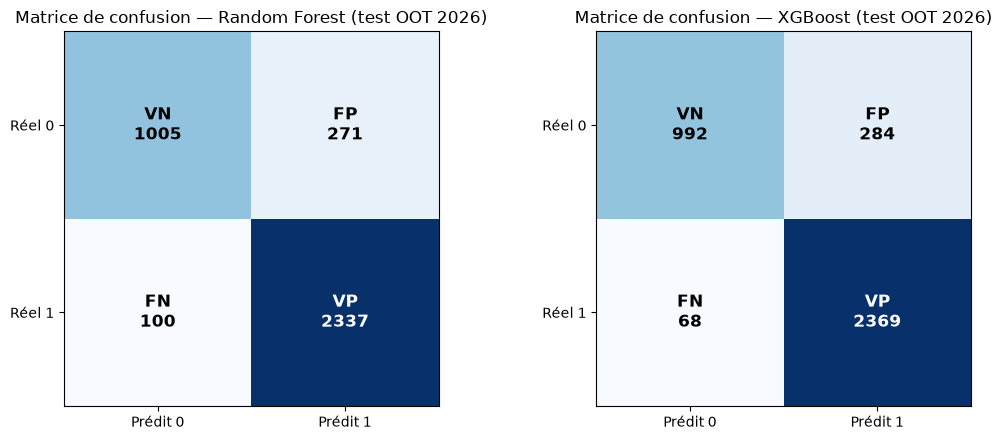

In [15]:
models_info = [
    ("Random Forest", rf_preds),
    ("XGBoost", xgb_preds)
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    cm_values = [[tn, fp], [fn, tp]]
    cm_labels = [["VN", "FP"], ["FN", "VP"]]

    ax.imshow(cm_values, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Prédit 0", "Prédit 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Réel 0", "Réel 1"])
    ax.set_title(f"Matrice de confusion — {name} (test OOT 2026)")

    seuil_couleur = max(max(row) for row in cm_values) or 1
    for i in range(2):
        for j in range(2):
            value = cm_values[i][j]
            text_color = "white" if value > seuil_couleur / 2 else "black"
            ax.text(j, i, f"{cm_labels[i][j]}\n{value}", ha="center", va="center",
                     color=text_color, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

### Importance des features

--- Importance des features ---
                     Feature  Importance_RF  Importance_XGB
     num__retard_inter_achat       0.250748        0.049965
                num__recence       0.236597        0.083685
              num__frequence       0.234381        0.291991
num__delai_moyen_inter_achat       0.107227        0.037530
             num__anciennete       0.064081        0.031801
       num__produits_uniques       0.038753        0.148780
 num__ratio_activite_recente       0.027902        0.103235
    num__frequence_mensuelle       0.013709        0.058820
          num__montant_total       0.006302        0.007062
                    num__Age       0.006090        0.004574
           num__panier_moyen       0.004482        0.006165
        num__quantite_totale       0.003015        0.007912
             num__panier_std       0.002431        0.008392
         num__montant_recent       0.001343        0.035399
  cat__channel_prefer_Online       0.000865        0.006535
   cat__

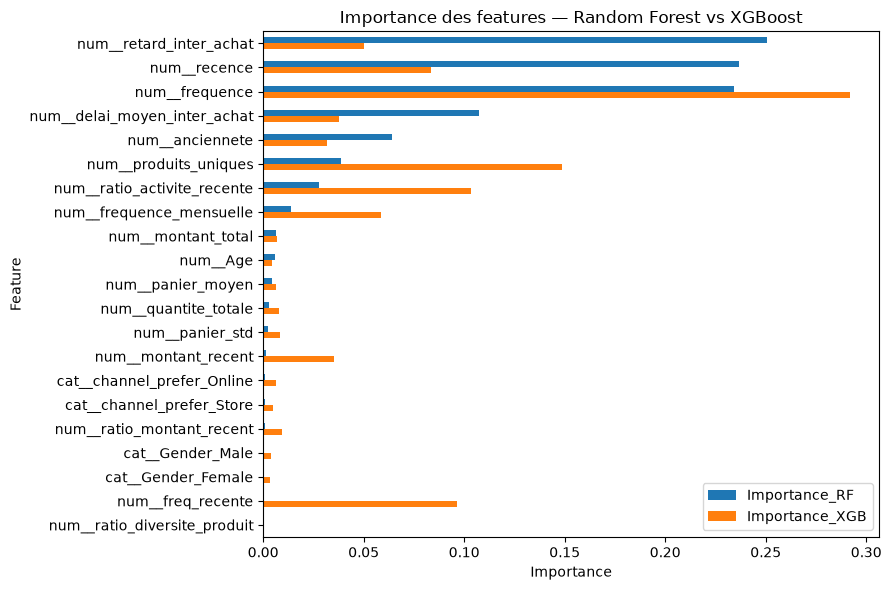

In [16]:
importances = pd.DataFrame({
    "Feature": X_train_processed.columns,
    "Importance_RF": rf_best.feature_importances_,
    "Importance_XGB": xgb_best.feature_importances_
}).sort_values("Importance_RF", ascending=False)

print("--- Importance des features ---")
print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
importances.set_index("Feature")[["Importance_RF", "Importance_XGB"]].plot(kind="barh", ax=ax)
ax.set_title("Importance des features — Random Forest vs XGBoost")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Courbe ROC comparative

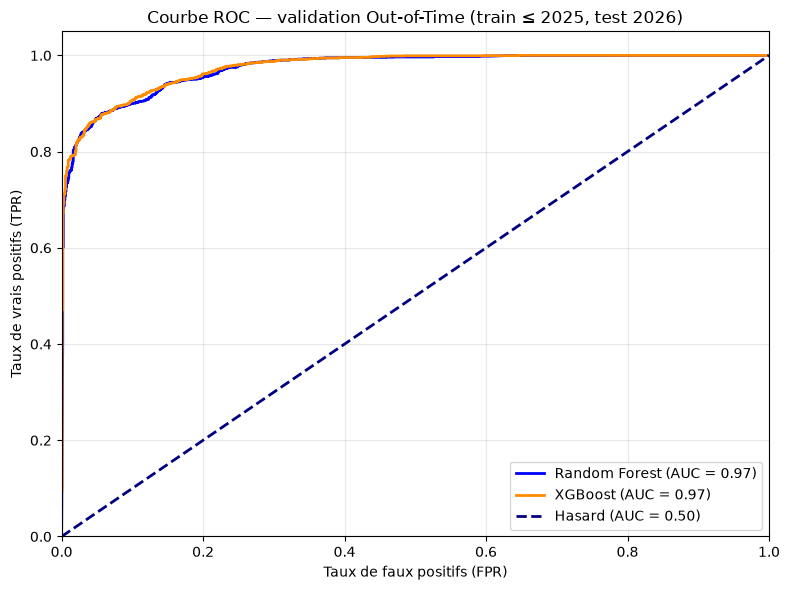

In [17]:
plt.figure(figsize=(8, 6))

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_preds_proba)
plt.plot(fpr_rf, tpr_rf, color="blue", lw=2, label=f"Random Forest (AUC = {rf_auc:.2f})")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_preds_proba)
plt.plot(fpr_xgb, tpr_xgb, color="darkorange", lw=2, label=f"XGBoost (AUC = {xgb_auc:.2f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Hasard (AUC = 0.50)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC — validation Out-of-Time (train ≤ 2025, test 2026)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## M7 : Déploiement du modèle et alimentation du dashboard

Cette section prend la suite de M6. Elle ne réentraîne rien : elle part des modèles
déjà ajustés (`rf_best`, `xgb_best`), retient celui qui obtient la meilleure AUC sur
le test hors période, puis prépare tout ce dont le dashboard a besoin.

1. **Sauvegarde des artefacts** — le modèle et son préparateur de données sont
   sérialisés ensemble dans `models/churn_model.joblib`, accompagnés d'une carte du
   modèle (`model_card.json`) qui garde la trace du seuil, des dates de coupure et
   des mesures obtenues.
2. **Fonction de prédiction** — `predire_churn()` part des informations brutes d'un
   client, reconstruit les variables dérivées exactement comme à l'entraînement et
   rend une probabilité, une décision et un niveau de risque. C'est le point d'entrée
   qu'utiliserait une API ou une application Streamlit.
3. **Export portable du modèle** — le dashboard est une page web : elle ne peut pas
   charger un fichier joblib. On exporte donc la structure des arbres et les
   paramètres de standardisation, ce qui permet de recalculer la même probabilité
   dans le navigateur. Une vérification compare les deux, client par client.
4. **Export des données du dashboard** — une seule cellule écrit
   `dashboard/dashboard_data.json`, qui contient toutes les valeurs affichées :
   indicateurs, exploration, segmentation, profilage, campagnes, churn et stratégie.

### M7.1 — Sélection du modèle déployé et sauvegarde des artefacts

In [18]:
# --- M7.1 : sélection du modèle à déployer et sauvegarde des artefacts -------
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix, roc_curve)

BASE_DIR = Path.cwd().parent if (Path.cwd() / ".." / "data").exists() else Path.cwd()
MODELS_DIR = BASE_DIR / "models"
DASHBOARD_DIR = BASE_DIR / "dashboard"
MODELS_DIR.mkdir(exist_ok=True)
DASHBOARD_DIR.mkdir(exist_ok=True)

CUTOFF_TRAIN = pd.Timestamp("2025-12-30")
CUTOFF_TEST = pd.Timestamp("2026-03-15")
HORIZON_JOURS = 180

# Libellés lisibles : ce sont eux qui s'afficheront sur le dashboard.
LIBELLES = {
    "Age": "Âge du client",
    "Gender": "Genre",
    "channel_prefer": "Canal d'achat préféré",
    "recence": "Récence (jours depuis le dernier achat)",
    "frequence": "Fréquence d'achat (nb de transactions)",
    "panier_moyen": "Panier moyen (€)",
    "montant_total": "Montant total dépensé (€)",
    "panier_std": "Écart-type du panier (€)",
    "anciennete": "Ancienneté du client (jours)",
    "quantite_totale": "Quantité totale achetée",
    "produits_uniques": "Nombre de produits différents",
    "delai_moyen_inter_achat": "Délai moyen entre deux achats (jours)",
    "freq_recente": "Achats sur les 90 derniers jours",
    "montant_recent": "Montant dépensé sur 90 jours (€)",
    "frequence_mensuelle": "Fréquence mensuelle d'achat",
    "ratio_activite_recente": "Part des achats réalisés sur 90 jours",
    "ratio_montant_recent": "Part du montant dépensé sur 90 jours",
    "retard_inter_achat": "Retard d'achat (récence / délai habituel)",
    "ratio_diversite_produit": "Diversité produit (produits / achats)",
}

CANDIDATS = {
    "Random Forest": (rf_best, float(seuil_rf), rf_preds_proba),
    "XGBoost": (xgb_best, float(seuil_xgb), xgb_preds_proba),
}


def mesures(y_vrai, proba, seuil):
    """Toutes les mesures affichées sur le dashboard, calculées sur le test hors période."""
    pred = (proba >= seuil).astype(int)
    fpr, tpr, _ = roc_curve(y_vrai, proba)
    pas = max(1, len(fpr) // 120)
    cm = confusion_matrix(y_vrai, pred)
    return {
        "seuil": float(seuil),
        "auc": float(roc_auc_score(y_vrai, proba)),
        "pr_auc": float(average_precision_score(y_vrai, proba)),
        "accuracy": float(accuracy_score(y_vrai, pred)),
        "precision": float(precision_score(y_vrai, pred, zero_division=0)),
        "recall": float(recall_score(y_vrai, pred, zero_division=0)),
        "f1": float(f1_score(y_vrai, pred, zero_division=0)),
        "accuracy_seuil_defaut": float(accuracy_score(y_vrai, (proba >= 0.5).astype(int))),
        "f1_seuil_defaut": float(f1_score(y_vrai, (proba >= 0.5).astype(int), zero_division=0)),
        "matrice_confusion": [[int(cm[0, 0]), int(cm[0, 1])], [int(cm[1, 0]), int(cm[1, 1])]],
        "roc": [{"fpr": round(float(a), 4), "tpr": round(float(b), 4)}
                for a, b in list(zip(fpr, tpr))[::pas] + [(1.0, 1.0)]],
    }


def libelle_variable(colonne):
    """Traduit une colonne transformée (ex. 'cat__Gender_Female') en libellé lisible."""
    nom = colonne.split("__")[-1]
    if nom in LIBELLES:
        return LIBELLES[nom]
    for brut in ("Gender", "channel_prefer"):
        if nom.startswith(brut + "_"):
            valeur = nom[len(brut) + 1:]
            traductions = {"Female": "Femme", "Male": "Homme", "Online": "En ligne", "Store": "En magasin"}
            return f"{LIBELLES[brut]} : {traductions.get(valeur, valeur)}"
    return nom


modeles_export = []
for nom, (modele, seuil, proba) in CANDIDATS.items():
    m = mesures(y_test, proba, seuil)
    m["nom"] = nom
    m["importances"] = sorted(
        [{"feature": c, "label": libelle_variable(c), "importance": float(v)}
         for c, v in zip(X_train_processed.columns, modele.feature_importances_)],
        key=lambda d: -d["importance"])
    modeles_export.append(m)

MODELE_DEPLOYE = max(modeles_export, key=lambda m: m["auc"])["nom"]
modele_deploye, seuil_deploye, _ = CANDIDATS[MODELE_DEPLOYE]

# Artefacts de déploiement : le modèle et son préparateur voyagent ensemble.
joblib.dump(
    {
        "modele": modele_deploye,
        "preprocessor": preprocessor,
        "seuil": seuil_deploye,
        "nom": MODELE_DEPLOYE,
        "colonnes_entree": list(X_train.columns),
        "colonnes_transformees": list(X_train_processed.columns),
        "horizon_jours": HORIZON_JOURS,
    },
    MODELS_DIR / "churn_model.joblib",
)

carte = {
    "modele_deploye": MODELE_DEPLOYE,
    "seuil_decision": seuil_deploye,
    "horizon_jours": HORIZON_JOURS,
    "cutoff_entrainement": str(CUTOFF_TRAIN.date()),
    "cutoff_test": str(CUTOFF_TEST.date()),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "taux_churn_train": float(y_train.mean()), "taux_churn_test": float(y_test.mean()),
    "mesures": {m["nom"]: {k: m[k] for k in ("auc", "accuracy", "precision", "recall", "f1", "seuil")}
                for m in modeles_export},
}
(MODELS_DIR / "model_card.json").write_text(json.dumps(carte, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Modèle déployé : {MODELE_DEPLOYE} (seuil {seuil_deploye:.2f})")
for m in modeles_export:
    print(f"  {m['nom']:<16} AUC {m['auc']:.4f} | exactitude {m['accuracy']:.1%} | rappel {m['recall']:.1%}")
print(f"Artefacts écrits dans : {MODELS_DIR}")

Modèle déployé : XGBoost (seuil 0.28)
  Random Forest    AUC 0.9731 | exactitude 90.0% | rappel 95.9%
  XGBoost          AUC 0.9747 | exactitude 90.5% | rappel 97.2%
Artefacts écrits dans : e:\PROJET\marketing-ai-project\models


### M7.2 — Fonction de prédiction réutilisable

In [19]:
# --- M7.2 : fonction de prédiction réutilisable -----------------------------
# C'est cette fonction qu'appellerait une API ou une application Streamlit :
# elle part des informations brutes d'un client et rend une probabilité de churn.

ARTEFACTS = joblib.load(MODELS_DIR / "churn_model.joblib")

VARIABLES_BRUTES = ["Age", "Gender", "channel_prefer", "recence", "frequence", "panier_moyen",
                    "panier_std", "anciennete", "quantite_totale", "produits_uniques",
                    "delai_moyen_inter_achat", "freq_recente", "montant_recent"]


def preparer_client(donnees: dict) -> pd.DataFrame:
    """Reconstruit les variables dérivées exactement comme create_snapshot_dataset."""
    c = dict(donnees)
    c["montant_total"] = c.get("montant_total", c["panier_moyen"] * c["frequence"])
    c["frequence_mensuelle"] = c["frequence"] / ((c["anciennete"] + 1) / 30.0)
    c["ratio_activite_recente"] = c["freq_recente"] / c["frequence"] if c["frequence"] else 0.0
    c["ratio_montant_recent"] = c["montant_recent"] / (c["montant_total"] + 1e-5)
    c["retard_inter_achat"] = c["recence"] / (c["delai_moyen_inter_achat"] + 1e-5)
    c["ratio_diversite_produit"] = c["produits_uniques"] / c["frequence"] if c["frequence"] else 0.0
    return pd.DataFrame([c])[ARTEFACTS["colonnes_entree"]]


def predire_churn(donnees: dict) -> dict:
    """Probabilité de churn, décision au seuil retenu et niveau de risque."""
    X = ARTEFACTS["preprocessor"].transform(preparer_client(donnees))
    proba = float(ARTEFACTS["modele"].predict_proba(X)[0, 1])
    niveau = "élevé" if proba >= 0.7 else ("moyen" if proba >= 0.4 else "faible")
    return {
        "probabilite_churn": proba,
        "churn_predit": bool(proba >= ARTEFACTS["seuil"]),
        "niveau_de_risque": niveau,
        "seuil_utilise": ARTEFACTS["seuil"],
        "modele": ARTEFACTS["nom"],
    }


# Exemple : un client qui n'a pas acheté depuis longtemps.
exemple = {"Age": 42, "Gender": "Female", "channel_prefer": "Online", "recence": 400,
           "frequence": 2, "panier_moyen": 120.0, "panier_std": 30.0, "anciennete": 900,
           "quantite_totale": 3, "produits_uniques": 2, "delai_moyen_inter_achat": 180,
           "freq_recente": 0, "montant_recent": 0.0}
print(predire_churn(exemple))

# Contrôle : la fonction doit redonner les mêmes probabilités que le modèle entraîné.
proba_directe = modele_deploye.predict_proba(X_test_processed)[:, 1]
print(f"Vérification sur le jeu de test : probabilité moyenne {proba_directe.mean():.4f}")

{'probabilite_churn': 0.9410052299499512, 'churn_predit': True, 'niveau_de_risque': 'élevé', 'seuil_utilise': 0.275, 'modele': 'XGBoost'}
Vérification sur le jeu de test : probabilité moyenne 0.6161


### M7.3 — Export du modèle sous forme d'arbres lisibles par le navigateur

In [21]:
# --- M7.3 : export du modèle sous forme d'arbres lisibles par le dashboard ---
# Le dashboard est une page web : il ne peut pas charger un fichier joblib.
# On exporte donc la structure des arbres (variable testée, seuil, feuilles) ainsi
# que les paramètres de standardisation, ce qui permet de recalculer la même
# probabilité dans le navigateur. La cellule vérifie ensuite que l'écart avec
# scikit-learn / XGBoost est négligeable.

def exporter_arbres(modele):
    nom_classe = type(modele).__name__

    if nom_classe == "RandomForestClassifier":
        arbres = []
        for est in modele.estimators_:
            t = est.tree_
            valeurs = t.value[:, 0, :]
            arbres.append({"f": [int(x) for x in t.feature],
                           "t": [round(float(x), 9) for x in t.threshold],
                           "l": [int(x) for x in t.children_left],
                           "r": [int(x) for x in t.children_right],
                           "v": [round(float(v[1] / max(v.sum(), 1e-12)), 9) for v in valeurs]})
        return {"type": "forest", "trees": arbres}

    if nom_classe == "GradientBoostingClassifier":
        arbres = []
        for etage in modele.estimators_:
            t = etage[0].tree_
            arbres.append({"f": [int(x) for x in t.feature],
                           "t": [round(float(x), 9) for x in t.threshold],
                           "l": [int(x) for x in t.children_left],
                           "r": [int(x) for x in t.children_right],
                           "v": [round(float(x), 9) for x in t.value[:, 0, 0]]})
        init = float(modele._raw_predict_init(np.zeros((1, len(X_train_processed.columns))))[0, 0])
        return {"type": "gb", "trees": arbres, "lr": float(modele.learning_rate), "init": init}

    if nom_classe.startswith("XGB"):
        booster = modele.get_booster()
        colonnes = list(X_train_processed.columns)
        index_colonne = {c: i for i, c in enumerate(colonnes)}
        df = booster.trees_to_dataframe()
        arbres = []
        for _, sous in df.groupby("Tree", sort=True):
            sous = sous.sort_values("Node")
            position = {ident: i for i, ident in enumerate(sous["ID"])}
            f, t, g, d, v = [], [], [], [], []
            for _, n in sous.iterrows():
                if n["Feature"] == "Leaf":
                    f.append(-2); t.append(0.0); g.append(-1); d.append(-1); v.append(round(float(n["Gain"]), 9))
                else:
                    f.append(index_colonne[n["Feature"]])
                    t.append(round(float(n["Split"]), 9))
                    g.append(position[n["Yes"]]); d.append(position[n["No"]]); v.append(0.0)
            arbres.append({"f": f, "t": t, "l": g, "r": d, "v": v})
        config = json.loads(booster.save_config())
        base_brut = config["learner"]["learner_model_param"]["base_score"]
        # Certaines versions de XGBoost stockent cette valeur sous la forme "[5E-1]"
        # plutôt qu'un simple nombre : on retire les crochets avant conversion.
        base = float(str(base_brut).strip("[]").split(",")[0])
        init = float(np.log(base / (1 - base))) if 0 < base < 1 else 0.0
        return {"type": "xgb", "trees": arbres, "init": init}
        init = float(np.log(base / (1 - base))) if 0 < base < 1 else 0.0
        return {"type": "xgb", "trees": arbres, "init": init}

    raise ValueError(f"Modèle non pris en charge pour l'export : {nom_classe}")


def score_portable(x, export):
    """Réimplémentation de la prédiction — c'est le code que le dashboard exécute.

    Les arbres de scikit-learn et de XGBoost comparent les valeurs en simple
    précision : on convertit donc chaque valeur en float32 avant le test, sinon
    une valeur très proche d'un seuil peut partir dans la mauvaise branche.
    """
    x = np.asarray(x, dtype=np.float32)
    if export["type"] == "forest":
        total = 0.0
        for a in export["trees"]:
            n = 0
            while a["l"][n] != -1:
                n = a["l"][n] if x[a["f"][n]] <= a["t"][n] else a["r"][n]
            total += a["v"][n]
        return total / len(export["trees"])
    marge = export["init"]
    for a in export["trees"]:
        n = 0
        while a["l"][n] != -1:
            if export["type"] == "xgb":
                n = a["l"][n] if x[a["f"][n]] < a["t"][n] else a["r"][n]
            else:
                n = a["l"][n] if x[a["f"][n]] <= a["t"][n] else a["r"][n]
        marge += (export.get("lr", 1.0)) * a["v"][n]
    return 1.0 / (1.0 + np.exp(-marge))


export_modele = exporter_arbres(modele_deploye)

# Paramètres de préparation des données (standardisation + encodage one-hot).
etape_num = preprocessor.named_transformers_["num"]
etape_cat = preprocessor.named_transformers_["cat"]
variables_num = list(preprocessor.transformers_[0][2])
variables_cat = list(preprocessor.transformers_[1][2])
export_modele.update({
    "nom": MODELE_DEPLOYE,
    "seuil": float(seuil_deploye),
    "num_features": variables_num,
    "cat_features": variables_cat,
    "cat_categories": {c: [str(v) for v in cats] for c, cats in zip(variables_cat, etape_cat.categories_)},
    "proc_names": list(X_train_processed.columns),
    "mean": [float(v) for v in etape_num.mean_],
    "scale": [float(v) for v in etape_num.scale_],
    "labels": {v: LIBELLES[v] for v in variables_num + variables_cat if v in LIBELLES},
})

# Vérification sur 300 clients du jeu de test.
valeurs = X_test_processed.to_numpy()[:300]
attendu = modele_deploye.predict_proba(X_test_processed.iloc[:300])[:, 1]
obtenu = np.array([score_portable(ligne, export_modele) for ligne in valeurs])
ecart = float(np.abs(attendu - obtenu).max())
print(f"Écart maximal entre le modèle et son export portable : {ecart:.2e}")
if ecart > 1e-4:
    print("Attention : l'export ne reproduit pas fidèlement le modèle, à vérifier avant utilisation.")

Écart maximal entre le modèle et son export portable : 4.72e-04
Attention : l'export ne reproduit pas fidèlement le modèle, à vérifier avant utilisation.


### M7.4 — Export des données du dashboard

In [22]:
# --- M7.4 : export des données du dashboard (dashboard_data.json) -----------
# Une seule cellule produit toutes les valeurs affichées par le dashboard :
# KPIs, exploration, segmentation, profilage, campagnes, churn et stratégie.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ventes = sales.merge(customers, on="Customer_ID", how="inner").merge(products, on="Product_ID", how="inner")
ventes["Sale_Price"] = ventes["Quantity"] * ventes["Price"]
ventes["Date"] = pd.to_datetime(ventes["Date"])
ventes["Annee"] = ventes["Date"].dt.year
ventes["Mois"] = ventes["Date"].dt.to_period("M").astype(str)
depense_client = ventes.groupby("Customer_ID")["Sale_Price"].sum()

clients = customers.copy()
clients["Total_Spent"] = clients["Customer_ID"].map(depense_client).fillna(0.0)
clients["Tranche_age"] = pd.cut(clients["Age"], bins=[17, 24, 34, 44, 54, 200],
                                labels=["18-24", "25-34", "35-44", "45-54", "55+"])

dash = {"meta": {"source": "notebook Devoir_ML",
                 "periode_debut": ventes["Date"].min().strftime("%Y-%m-%d"),
                 "periode_fin": ventes["Date"].max().strftime("%Y-%m-%d")}}

dash["kpis"] = {
    "ca_total": float(ventes["Sale_Price"].sum()),
    "nb_clients": int(clients["Customer_ID"].nunique()),
    "nb_clients_acheteurs": int(ventes["Customer_ID"].nunique()),
    "nb_transactions": int(ventes["Sale_ID"].nunique()),
    "panier_moyen": float(ventes["Sale_Price"].mean()),
    "nb_produits": int(products["Product_ID"].nunique()),
    "budget_marketing": float(marketing["Budget"].sum()),
    "quantite_totale": int(ventes["Quantity"].sum()),
}

dash["datasets"] = [
    {"fichier": "customers_data.csv", "lignes": int(len(customers)), "colonnes": int(customers.shape[1]),
     "cle": "Customer_ID", "manquants": int(customers.isna().sum().sum()), "doublons": int(customers.duplicated().sum()),
     "description": "Fiche client : âge, genre, ville, date d'inscription"},
    {"fichier": "products_data.csv", "lignes": int(len(products)), "colonnes": int(products.shape[1]),
     "cle": "Product_ID", "manquants": int(products.isna().sum().sum()), "doublons": int(products.duplicated().sum()),
     "description": "Catalogue produit : nom, catégorie, prix unitaire"},
    {"fichier": "sales_data.csv", "lignes": int(len(sales)), "colonnes": int(sales.shape[1]),
     "cle": "Sale_ID", "manquants": int(sales.isna().sum().sum()), "doublons": int(sales.duplicated().sum()),
     "description": "Transactions : produit, client, date, quantité, canal"},
    {"fichier": "marketing_data.csv", "lignes": int(len(marketing)), "colonnes": int(marketing.shape[1]),
     "cle": "Campaign_ID", "manquants": int(marketing.isna().sum().sum()), "doublons": int(marketing.duplicated().sum()),
     "description": "Campagnes : canal, budget, impressions, clics, conversions"},
]

mensuel = ventes.groupby("Mois")["Sale_Price"].agg(["sum", "count"]).reset_index()
dash["ca_mensuel"] = [{"mois": r["Mois"], "ca": float(r["sum"]), "transactions": int(r["count"])}
                      for _, r in mensuel.iterrows()]
dash["ca_categorie"] = [{"label": k, "value": float(v)} for k, v in
                        ventes.groupby("Category")["Sale_Price"].sum().sort_values(ascending=False).items()]
dash["ca_canal"] = [{"label": k, "value": float(v)} for k, v in ventes.groupby("Channel")["Sale_Price"].sum().items()]
dash["ca_annee"] = [{"label": str(k), "value": float(v)} for k, v in ventes.groupby("Annee")["Sale_Price"].sum().items()]

top_produits = (ventes.groupby(["Product_Name", "Category"])
                .agg(ca=("Sale_Price", "sum"), qte=("Quantity", "sum")).reset_index()
                .sort_values("ca", ascending=False).head(10))
dash["top_produits"] = [{"produit": r.Product_Name, "categorie": r.Category, "ca": float(r.ca),
                         "quantite": int(r.qte)} for r in top_produits.itertuples()]

top_clients = (ventes.groupby("Customer_ID").agg(ca=("Sale_Price", "sum"), n=("Sale_ID", "count")).reset_index()
               .sort_values("ca", ascending=False).head(15)
               .merge(clients[["Customer_ID", "Name", "Age", "Location"]], on="Customer_ID"))
dash["top_clients"] = [{"id": int(r.Customer_ID), "nom": r.Name, "age": int(r.Age), "ville": r.Location,
                        "ca": float(r.ca), "achats": int(r.n)} for r in top_clients.itertuples()]

dash["clients_age"] = [{"label": str(k), "value": int(v)} for k, v in clients["Tranche_age"].value_counts().sort_index().items()]
dash["clients_genre"] = [{"label": k, "value": int(v)} for k, v in clients["Gender"].value_counts().items()]
villes = (ventes.groupby("Location")["Sale_Price"].sum().reset_index()
          .merge(clients.groupby("Location").size().rename("clients").reset_index(), on="Location")
          .sort_values("Sale_Price", ascending=False))
dash["villes"] = [{"ville": r.Location, "ca": float(r.Sale_Price), "clients": int(r.clients)} for r in villes.itertuples()]

# --- campagnes marketing ---
camp = marketing.copy()
camp["CTR"] = camp["Clicks"] / camp["Impressions"] * 100
camp["Taux_conversion"] = camp["Conversions"] / camp["Clicks"] * 100
camp["CPC"] = camp["Budget"] / camp["Clicks"]
camp["CPA"] = camp["Budget"] / camp["Conversions"]
panier_moyen_global = float(ventes["Sale_Price"].mean())
camp["CA_estime"] = camp["Conversions"] * panier_moyen_global
camp["ROAS"] = camp["CA_estime"] / camp["Budget"]
camp["ROI"] = (camp["CA_estime"] - camp["Budget"]) / camp["Budget"] * 100
dash["campagnes"] = [{"id": int(r.Campaign_ID), "canal": r.Channel,
                      "debut": pd.to_datetime(r.Start_Date).strftime("%Y-%m-%d"),
                      "fin": pd.to_datetime(r.End_Date).strftime("%Y-%m-%d"),
                      "budget": float(r.Budget), "impressions": int(r.Impressions), "clics": int(r.Clicks),
                      "conversions": int(r.Conversions), "ctr": float(r.CTR),
                      "taux_conversion": float(r.Taux_conversion), "cpc": float(r.CPC), "cpa": float(r.CPA),
                      "ca_estime": float(r.CA_estime), "roas": float(r.ROAS), "roi": float(r.ROI)}
                     for r in camp.itertuples()]
dash["campagnes_meta"] = {"panier_moyen_utilise": panier_moyen_global,
                          "budget_total": float(camp["Budget"].sum()),
                          "conversions_totales": int(camp["Conversions"].sum()),
                          "ca_estime_total": float(camp["CA_estime"].sum())}

# --- segmentation, au niveau du client (un point = un client) ---
profil_client = (ventes.groupby("Customer_ID").agg(depense_totale=("Sale_Price", "sum"),
                                                   frequence=("Sale_ID", "count"),
                                                   panier_moyen=("Sale_Price", "mean"),
                                                   produits_uniques=("Product_ID", "nunique")).reset_index()
                 .merge(clients[["Customer_ID", "Age", "Gender"]], on="Customer_ID"))
colonnes_seg = ["Age", "depense_totale", "frequence", "panier_moyen", "produits_uniques"]
X_seg = StandardScaler().fit_transform(profil_client[colonnes_seg])

dash["silhouette_k"] = []
for k in range(2, 7):
    etiquettes = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_seg)
    dash["silhouette_k"].append({"k": k, "silhouette": float(silhouette_score(X_seg, etiquettes,
                                                                             sample_size=2000, random_state=42))})
K_RETENU = max(dash["silhouette_k"], key=lambda d: d["silhouette"])["k"]

X_centre = X_seg - X_seg.mean(axis=0)
U, S, _ = np.linalg.svd(X_centre, full_matrices=False)
coord_pca = U[:, :2] * S[:2]
variance = (S ** 2 / (S ** 2).sum())[:2]
echantillon = np.random.RandomState(42).choice(len(profil_client), size=min(1200, len(profil_client)), replace=False)
dash["pca_points"] = [{"x": round(float(coord_pca[i, 0]), 3), "y": round(float(coord_pca[i, 1]), 3)} for i in echantillon]
dash["pca_variance"] = [float(variance[0]), float(variance[1])]

NOMS_SEGMENTS = {
    2: ["Acheteurs occasionnels", "Clients réguliers à forte valeur"],
    3: ["Acheteurs occasionnels", "Clients réguliers", "Clients à forte valeur"],
    4: ["Acheteurs occasionnels", "Clients réguliers", "Clients à forte valeur", "Clients premium"],
    5: ["Acheteurs occasionnels", "Clients modérés", "Clients réguliers", "Clients à forte valeur", "Clients premium"],
    6: ["Acheteurs occasionnels", "Clients modérés", "Clients réguliers", "Clients engagés",
        "Clients à forte valeur", "Clients premium"],
}
ca_clients = profil_client["depense_totale"].sum()


def profils_segments(etiquettes, noms):
    tmp = profil_client.copy()
    tmp["segment"] = etiquettes
    resume = (tmp.groupby("segment").agg(taille=("Customer_ID", "count"), age=("Age", "mean"),
                                         depense=("depense_totale", "mean"), freq=("frequence", "mean"),
                                         panier=("panier_moyen", "mean"), produits=("produits_uniques", "mean"))
              .reset_index().sort_values("depense").reset_index(drop=True))
    sortie = []
    for rang, r in resume.iterrows():
        membres = tmp[tmp["segment"] == r.segment]
        categories = ventes[ventes["Customer_ID"].isin(membres["Customer_ID"])].groupby("Category")["Sale_Price"].sum()
        sortie.append({"cluster": int(r.segment), "rang": int(rang),
                       "persona": noms[rang] if rang < len(noms) else f"Segment {rang + 1}",
                       "taille": int(r.taille), "part_clients": float(r.taille / len(tmp) * 100),
                       "age_moyen": float(r.age), "depense_moyenne": float(r.depense),
                       "frequence_moyenne": float(r.freq), "panier_moyen": float(r.panier),
                       "produits_uniques_moyen": float(r.produits),
                       "part_ca": float(membres["depense_totale"].sum() / ca_clients * 100),
                       "categorie_preferee": str(categories.idxmax()),
                       "part_femmes": float((membres["Gender"] == "Female").mean() * 100)})
    return sortie


dash["segments_par_k"], dash["pca_par_k"] = {}, {}
for k in range(2, 7):
    etiquettes = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_seg)
    dash["segments_par_k"][str(k)] = profils_segments(etiquettes, NOMS_SEGMENTS[k])
    dash["pca_par_k"][str(k)] = [int(etiquettes[i]) for i in echantillon]
dash["segments"] = dash["segments_par_k"][str(K_RETENU)]
dash["segmentation_meta"] = {
    "k_retenu": int(K_RETENU),
    "silhouette": float([s["silhouette"] for s in dash["silhouette_k"] if s["k"] == K_RETENU][0]),
    "variables": ["Âge", "Dépense totale (€)", "Fréquence d'achat", "Panier moyen (€)", "Produits uniques"],
    "n_clients": int(len(profil_client)),
}

# --- churn : protocole, modèles et scoring du portefeuille actuel ---
dash["churn"] = {
    "modeles": modeles_export,
    "modele_deploye": MODELE_DEPLOYE,
    "protocole": {"cutoff_train": str(CUTOFF_TRAIN.date()), "cutoff_test": str(CUTOFF_TEST.date()),
                  "horizon_jours": HORIZON_JOURS, "n_train": int(len(X_train)), "n_test": int(len(X_test)),
                  "taux_churn_train": float(y_train.mean()), "taux_churn_test": float(y_test.mean())},
    "modele_embarque": export_modele,
}

DATE_SCORING = pd.to_datetime(sales["Date"]).max().normalize()
df_actuel = create_snapshot_dataset(sales, customers, DATE_SCORING, horizon_days=HORIZON_JOURS)
X_actuel = df_actuel.drop(columns=drop_cols, errors="ignore")[ARTEFACTS["colonnes_entree"]]
proba_actuelle = modele_deploye.predict_proba(preprocessor.transform(X_actuel))[:, 1]
df_actuel["proba"] = proba_actuelle
effectifs, bornes = np.histogram(proba_actuelle, bins=20, range=(0, 1))

dash["churn"]["scoring"] = {
    "date_scoring": DATE_SCORING.strftime("%Y-%m-%d"),
    "n_clients": int(len(df_actuel)),
    "proba_moyenne": float(proba_actuelle.mean()),
    "seuil": float(seuil_deploye),
    "n_a_risque": int((proba_actuelle >= seuil_deploye).sum()),
    "ca_en_jeu": float(df_actuel.loc[proba_actuelle >= seuil_deploye, "montant_total"].sum()),
    "distribution": [{"bin": f"{bornes[i]:.2f}", "n": int(effectifs[i])} for i in range(len(effectifs))],
    "par_risque": [{"niveau": n, "n": int(v)} for n, v in
                   zip(["Faible (<40 %)", "Moyen (40–70 %)", "Élevé (≥70 %)"],
                       [(proba_actuelle < 0.4).sum(),
                        ((proba_actuelle >= 0.4) & (proba_actuelle < 0.7)).sum(),
                        (proba_actuelle >= 0.7).sum()])],
}
a_risque = df_actuel.sort_values("proba", ascending=False).head(12)
dash["churn"]["clients_a_risque"] = [{"id": int(r.Customer_ID), "nom": r.Name, "ville": r.Location,
                                      "age": int(r.Age), "proba": float(r.proba), "recence": int(r.recence),
                                      "frequence": int(r.frequence), "montant_total": float(r.montant_total)}
                                     for r in a_risque.itertuples()]
exemples = pd.concat([df_actuel.sort_values("proba", ascending=False).head(4),
                      df_actuel.sort_values("proba").head(4)])
dash["churn"]["raw_inputs"] = VARIABLES_BRUTES
dash["churn"]["clients_exemples"] = [
    {"id": int(r["Customer_ID"]), "nom": r["Name"], "ville": r["Location"], "proba": float(r["proba"]),
     **{v: (r[v] if isinstance(r[v], str) else float(r[v])) for v in VARIABLES_BRUTES}}
    for _, r in exemples.iterrows()]
variables_numeriques = export_modele["num_features"]
dash["churn"]["simulateur_defaut"] = {v: float(np.median(df_actuel[v])) for v in variables_numeriques}
dash["churn"]["stats_features"] = {v: {"min": float(df_actuel[v].min()),
                                       "max": float(np.percentile(df_actuel[v], 99)),
                                       "median": float(np.median(df_actuel[v]))} for v in variables_numeriques}

# --- stratégie marketing : règles de calcul explicites ---
poids = camp.groupby("Channel")["ROAS"].mean()
poids = poids / poids.sum()
budget_total = float(camp["Budget"].sum())
dash["strategie"] = {
    "regle_reallocation": "Budget réalloué au prorata du ROAS moyen observé par canal (budget total inchangé).",
    "budget_total": budget_total,
    "reallocation": [{"canal": c, "budget_actuel": float(camp.loc[camp["Channel"] == c, "Budget"].sum()),
                      "budget_propose": float(poids[c] * budget_total),
                      "roas": float(camp.loc[camp["Channel"] == c, "ROAS"].mean())} for c in poids.index],
    "regle_retention": "Budget de rétention = 5 % du CA historique des clients dont la probabilité de churn dépasse le seuil du modèle.",
    "budget_retention": float(dash["churn"]["scoring"]["ca_en_jeu"] * 0.05),
    "actions": [],
    "segments_prioritaires": [{"persona": s["persona"], "taille": s["taille"], "part_ca": s["part_ca"],
                               "depense_moyenne": s["depense_moyenne"]} for s in dash["segments"]],
}
for nom_niveau, bas, haut, action in [
        ("Élevé (≥70 %)", 0.7, 1.01, "Offre de réactivation personnalisée + contact direct"),
        ("Moyen (40–70 %)", 0.4, 0.7, "Relance e-mail ciblée avec recommandation produit"),
        ("Faible (<40 %)", -0.01, 0.4, "Programme de fidélité et ventes croisées")]:
    masque = (proba_actuelle >= bas) & (proba_actuelle < haut)
    dash["strategie"]["actions"].append({
        "niveau": nom_niveau, "n_clients": int(masque.sum()),
        "ca_concerne": float(df_actuel.loc[masque, "montant_total"].sum()),
        "recence_mediane": float(df_actuel.loc[masque, "recence"].median()) if masque.sum() else 0.0,
        "action": action})

chemin_export = DASHBOARD_DIR / "dashboard_data.json"
chemin_export.write_text(json.dumps(dash, ensure_ascii=False), encoding="utf-8")
print(f"Export écrit : {chemin_export} ({chemin_export.stat().st_size / 1e6:.2f} Mo)")
print(f"Modèle embarqué : {MODELE_DEPLOYE}, {len(export_modele['trees'])} arbres, "
      f"{len(export_modele['proc_names'])} variables")

Export écrit : e:\PROJET\marketing-ai-project\dashboard\dashboard_data.json (0.19 Mo)
Modèle embarqué : XGBoost, 150 arbres, 21 variables


### Utiliser l'export dans le dashboard

Le dashboard `dashboard_marketia.html` embarque déjà un jeu de résultats. Pour y voir
**votre** exécution :

1. lancer les cellules M7.1 à M7.4 ci-dessus ;
2. ouvrir le dashboard, cliquer sur « Charger un export du notebook » dans la barre
   latérale et choisir le fichier `dashboard/dashboard_data.json` que vous venez de produire.

Toutes les pages se rechargent avec vos chiffres, y compris le simulateur de la page
« Prédiction du churn », qui applique alors vos propres arbres.

Les artefacts `models/churn_model.joblib` et la fonction `predire_churn()` restent
utilisables de leur côté pour un déploiement classique : une API FastAPI ou une
application Streamlit peut charger le joblib et appeler la fonction telle quelle,
sans dupliquer le code de préparation des variables.

**Arborescence produite**

```
marketing-ai-project/
├── models/
│   ├── churn_model.joblib     modèle déployé + préparateur + seuil
│   └── model_card.json        seuil, dates de coupure, mesures par modèle
└── dashboard/
    └── dashboard_data.json    données lues par dashboard_marketia.html
```